Implement SIFT based image matching between 2 images and visualize the matched keypoints

In [1]:
!pip install opencv-python-headless numpy matplotlib

Image 1 loaded: (1024, 1024)
Image 2 loaded: (225, 225)


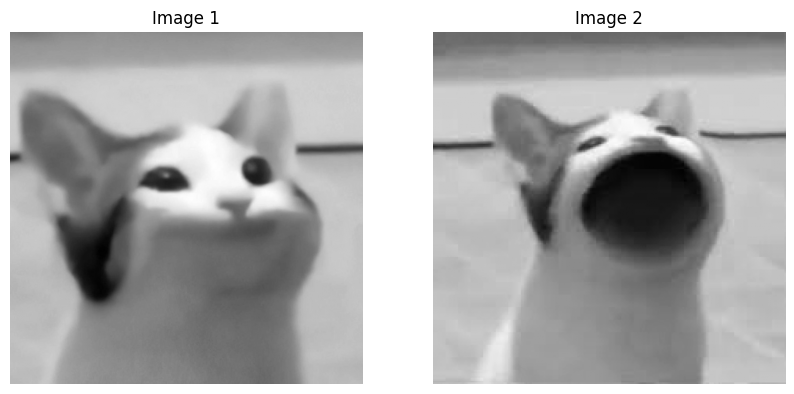

In [7]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import urllib.request

img_path1 = '/content/pop closed.png'
img_path2 = '/content/pop opened.png'

# Load the images in grayscale
img1 = cv2.imread(img_path1, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(img_path2, cv2.IMREAD_GRAYSCALE)

if img1 is None or img2 is None:
    print("Error: Could not load one or both images. Please check the paths.")
else:
    print(f"Image 1 loaded: {img1.shape}")
    print(f"Image 2 loaded: {img2.shape}")

    # Display the images
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img1, cmap='gray')
    axes[0].set_title('Image 1')
    axes[0].axis('off')
    axes[1].imshow(img2, cmap='gray')
    axes[1].set_title('Image 2')
    axes[1].axis('off')
    plt.show()


Number of keypoints found in Image 1: 36
Number of keypoints found in Image 2: 45


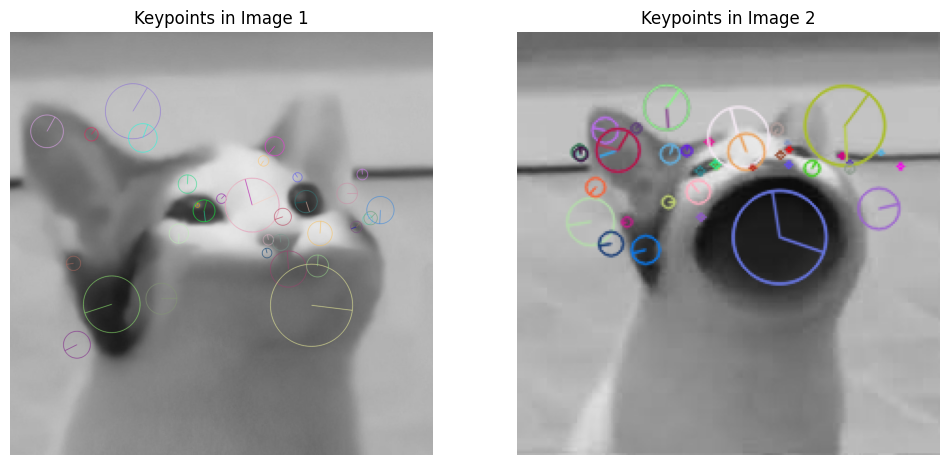

In [8]:
# Create SIFT detector object
sift = cv2.SIFT_create()

# Find keypoints and descriptors in both images
kp1, des1 = sift.detectAndCompute(img1, None)
kp2, des2 = sift.detectAndCompute(img2, None)

print(f"Number of keypoints found in Image 1: {len(kp1)}")
print(f"Number of keypoints found in Image 2: {len(kp2)}")

# Visualize keypoints on the images
img1_kp = cv2.drawKeypoints(img1, kp1, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
img2_kp = cv2.drawKeypoints(img2, kp2, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img1_kp)
axes[0].set_title('Keypoints in Image 1')
axes[0].axis('off')
axes[1].imshow(img2_kp)
axes[1].set_title('Keypoints in Image 2')
axes[1].axis('off')
plt.show()


In [9]:
# Create Brute-Force Matcher object
bf = cv2.BFMatcher(cv2.NORM_L2, crossCheck=False) # Set crossCheck to False for ratio test

# Match descriptors
matches = bf.knnMatch(des1, des2, k=2)

# Apply ratio test to filter good matches
good_matches = []
for m, n in matches:
    if m.distance < 0.75 * n.distance:
        good_matches.append(m)

print(f"Number of raw matches: {len(matches)}")
print(f"Number of good matches after ratio test: {len(good_matches)}")


Number of raw matches: 36
Number of good matches after ratio test: 5


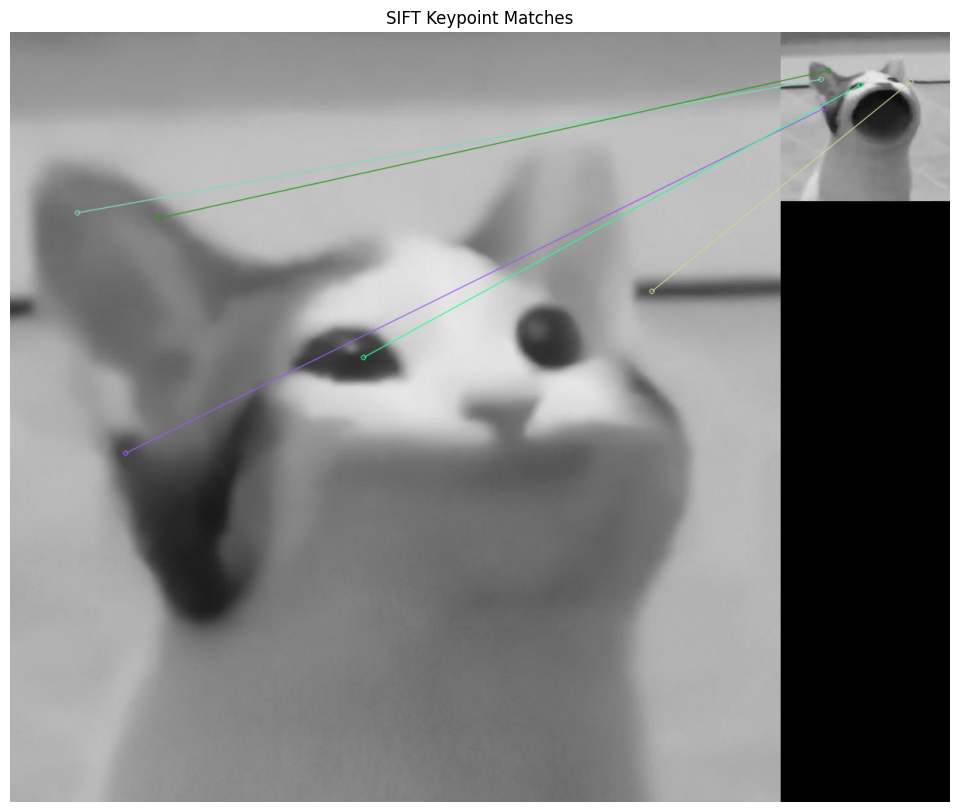

In [10]:
# Draw only good matches
img_matches = cv2.drawMatches(img1, kp1, img2, kp2, good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

plt.figure(figsize=(15, 10))
plt.imshow(img_matches)
plt.title('SIFT Keypoint Matches')
plt.axis('off')
plt.show()
